# The Brasileirão dataset — first look

The Campeonato Brasileiro Série A ("Brasileirão") is the top flight of Brazilian
men's football — one round-robin league table, no playoffs, decided over roughly
38 matchdays a year, similar in structure to England's Premier League or Spain's
La Liga. This notebook loads the full match history (2003–2024), sourced from a
public dataset of official results, and takes a first look at it before we dig
into the article's central question: why is home advantage in Brazil unusually
large?

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from brasileirao import analysis, ingest, plotting

plotting.style()
matches = ingest.load()
print(f"{len(matches)} matches, seasons {matches.season.min()}-{matches.season.max()}")
matches.tail(3)

8785 matches, seasons 2003-2024


,date,season,home_team,away_team,home_goals,away_goals,outcome,stadium,home_state,away_state
8782,2024-12-08,2024,Juventude,Cruzeiro,0,1,A,Alfredo Jaconi,RS,MG
8783,2024-12-08,2024,Atletico-MG,Athletico-PR,1,0,H,Arena MRV,MG,PR
8784,2024-12-08,2024,Gremio,Corinthians,0,3,A,Arena do Grêmio,RS,SP


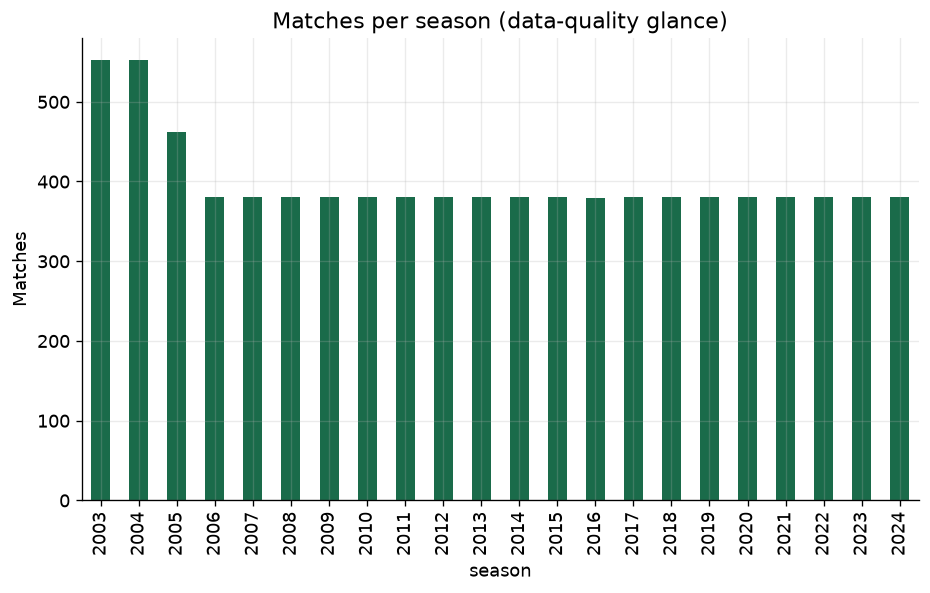

In [2]:
matches.groupby("season").size().plot.bar(color=plotting.COLORS["main"])
plt.ylabel("Matches")
plt.title("Matches per season (data-quality glance)")
plt.show()

Early seasons have noticeably more matches: the league fielded 24 clubs in
2003–2004 and 22 in 2005, before settling at the current 20-club, 38-round
format from 2006 onward. That's a data-quality quirk to keep in mind, not a
signal — season-level comparisons below are unaffected because our metric is a
*share* of points, not a count of matches.

## The anchor chart: home advantage over two decades

Our core metric is the **home points share**: of all league points actually
awarded in a season (3 for a win, 1 each for a draw), what fraction went to the
home team? A value of 0.5 would mean home teams and away teams earned points at
exactly the same rate — no home advantage at all. Anything above 0.5 is home
advantage; below 0.5 would mean an *away* advantage.

Because a draw hands out only 2 total points instead of 3, this share sits well
above the naive "home win rate" most fans have in their head — even a league
with a fairly modest edge for home teams can show numbers in the 0.55–0.65
range once the accounting is done this way.

One season stands out for a reason that has nothing to do with tactics: 2020,
played behind closed doors during the COVID-19 pandemic. But look closely at
the chart below and you'll notice 2017 and 2022 actually dip *lower* than 2020,
even though both were played with full stadiums — season-level swings here are
large enough that no single season proves anything about crowds on its own.
That's exactly why notebook `02_home_advantage_story.ipynb` tests the
closed-door *window* against neighbouring control seasons match by match,
rather than reading the story off one point per season.

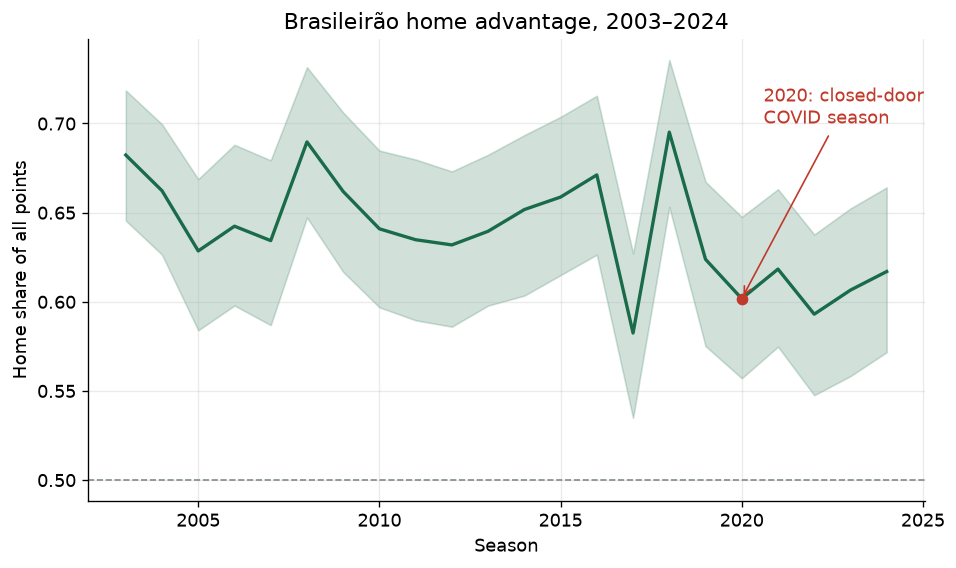

In [3]:
by_season = matches.groupby("season").apply(analysis.home_points_share, include_groups=False)
cis = {
    s: analysis.bootstrap_ci(g, analysis.home_points_share)
    for s, g in matches.groupby("season")
}
lo = [cis[s][0] for s in by_season.index]
hi = [cis[s][1] for s in by_season.index]

fig, ax = plt.subplots()
ax.plot(by_season.index, by_season.values, color=plotting.COLORS["main"], lw=2)
ax.fill_between(by_season.index, lo, hi, color=plotting.COLORS["main"], alpha=0.2)
ax.axhline(0.5, color=plotting.COLORS["muted"], ls="--", lw=1)
ax.plot([2020], [by_season.loc[2020]], "o", color=plotting.COLORS["accent"], zorder=5)
ax.annotate("2020: closed-door\nCOVID season", xy=(2020, by_season.loc[2020]),
            xytext=(2020.6, 0.70), ha="left",
            arrowprops=dict(arrowstyle="->", color=plotting.COLORS["accent"]),
            color=plotting.COLORS["accent"])
ax.set(xlabel="Season", ylabel="Home share of all points",
       title="Brasileirão home advantage, 2003–2024")
plotting.save(fig, "home_points_share")

## Two tables, one club

A season table blends each club's home and away results into a single ranking.
Split it in two — a home-only table and an away-only table — and the same club
looks like it's living two different competitive lives. The gap between a
club's home points and away points, in the same season, is a quick way to see
how much of its position in the standings depends on where it plays.

In [4]:
last = matches[matches.season == matches.season.max()]
home_pts = last.groupby("home_team")["outcome"].apply(
    lambda s: s.map(analysis.HOME_POINTS).sum()).rename("home_pts")
away_pts = last.groupby("away_team")["outcome"].apply(
    lambda s: s.map(analysis.AWAY_POINTS).sum()).rename("away_pts")
tables = pd.concat([home_pts, away_pts], axis=1).fillna(0).astype(int)
tables["gap"] = tables.home_pts - tables.away_pts
tables.sort_values("gap", ascending=False).head(10)

,home_pts,away_pts,gap
Fortaleza,47,21,26
Corinthians,38,18,20
Vasco,35,15,20
Bahia,36,17,19
Sao Paulo,39,20,19
Cruzeiro,35,17,18
Bragantino,31,13,18
Juventude,30,15,15
Gremio,29,16,13
Fluminense,29,17,12


## How does this compare to Europe?

Brazil isn't the only country where home advantage exists — but is it unusually
*large*? As a teaser, we apply the exact same home-points-share metric to two
of Europe's biggest leagues, the Premier League and La Liga, over the same
pre-COVID window (2015–2018 seasons) used for the Brasileirão comparison. Data
comes from football-data.co.uk season CSVs, cached locally in `data/raw/`.

{'Premier League': np.float64(0.5846630150035723),
 'La Liga': np.float64(0.6000478125747072),
 'Brasileirão': np.float64(0.6518393844674201)}

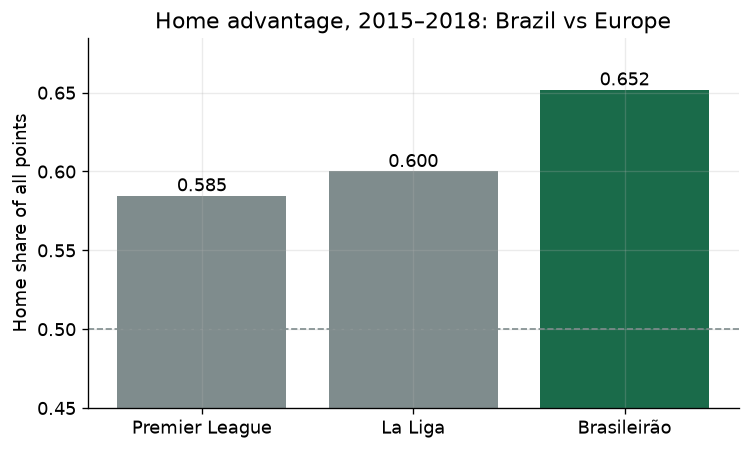

In [5]:
import urllib.request

from brasileirao.paths import RAW

SEASONS = ["1516", "1617", "1718", "1819"]
LEAGUES = {"Premier League": "E0", "La Liga": "SP1"}

shares = {}
for league, code in LEAGUES.items():
    frames = []
    for s in SEASONS:
        f = RAW / f"{code}_{s}.csv"
        if not f.exists():
            urllib.request.urlretrieve(
                f"https://www.football-data.co.uk/mmz4281/{s}/{code}.csv", f)
        frames.append(pd.read_csv(f, usecols=["FTR"]))
    eu = pd.concat(frames).rename(columns={"FTR": "outcome"})
    shares[league] = analysis.home_points_share(eu)
shares["Brasileirão"] = analysis.home_points_share(
    matches[matches.season.between(2015, 2018)])

fig, ax = plt.subplots(figsize=(7, 4))
names = list(shares)
vals = [shares[n] for n in names]
bars = ax.bar(names, vals, color=[plotting.COLORS["muted"]] * 2
              + [plotting.COLORS["main"]])
ax.bar_label(bars, fmt="%.3f")
ax.axhline(0.5, color=plotting.COLORS["muted"], ls="--", lw=1)
ax.set(ylabel="Home share of all points", ylim=(0.45, None),
       title="Home advantage, 2015–2018: Brazil vs Europe")
plotting.save(fig, "cross_league_home_advantage")
shares

## What's next

Over the 2015–2018 seasons, Brazilian home teams took roughly **65% of all
points on offer**, compared to about **60% in La Liga** and **58% in the
Premier League** — a gap of some 5 to 7 percentage points over Europe's two
biggest leagues, using the identical metric on the identical window. That gap
is real, but the whole-season view above is noisy: notice that 2020, the
closed-door COVID season, sits in the *bottom tier* of seasons but is not
actually the lowest — 2017 and 2022 were lower still, for reasons that have
nothing to do with crowds. A cleaner test of the crowd effect needs to compare
matches, not whole seasons: notebook `02_home_advantage_story.ipynb` isolates
the closed-door window against contemporaneous control seasons and adds
travel distance and heat/altitude differences to the picture.